# MISOCP Global

Adaptive global MISOCP notebook. It first attempts a single-window solve, then falls back to chunked windows when needed.
Chunked results are treated as near-optimal references rather than global oracles.

> Validation fix baseline recorded before the root-power / reactive-base / tie-breaker repairs:
> `max_root_p_abs_err_kw ~= 148.8`, `max_trafo_loading_abs_err_pct ~= 52.7`.
>
> Current post-fix baseline recorded before the slack / root-q / root-fit diagnostics enhancement:
> `max_root_p_abs_err_kw ~= 48`, `max_trafo_loading_abs_err_pct ~= 52`.
>
> Floor-check / refinement gate will next focus on `p95_soc_slack`, `floor_mean_abs_solver_feeder_gap_kw`, and the resulting `physics_refinement_status`.


In [ ]:
from pathlib import Path
import hashlib
import importlib
import sys

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "configs").exists():
    project_root = project_root.parent
if not (project_root / "configs").exists():
    raise RuntimeError("Could not locate the project root from the notebook working directory.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import configs as configs_pkg
from configs import experiment_config as config_core
from configs import profiles as config_profiles
from controllers import mpc as mpc_pkg
from controllers.mpc import global_socp_mpc as misocp_core
from scripts.builder import build_env
from scripts.utils import grid_notebook_workflow as grid_nb
from scripts.utils import misocp_notebook_helpers as misocp_nb

config_core = importlib.reload(config_core)
config_profiles = importlib.reload(config_profiles)
configs_pkg = importlib.reload(configs_pkg)
mpc_pkg = importlib.reload(mpc_pkg)
misocp_core = importlib.reload(misocp_core)
grid_nb = importlib.reload(grid_nb)
misocp_nb = importlib.reload(misocp_nb)
compose_experiment_config = config_profiles.compose_experiment_config
print(f"Reloaded config core from: {config_core.__file__}")
print(f"Reloaded config profiles from: {config_profiles.__file__}")
print(f"Reloaded controllers.mpc package from: {getattr(mpc_pkg, '__file__', '<package>')}")
print(f"Reloaded MISOCP solver core from: {misocp_core.__file__}")
print(f"Reloaded grid notebook helpers from: {grid_nb.__file__}")
print(f"Reloaded MISOCP notebook helpers from: {misocp_nb.__file__}")

FullHorizonProblemInput = misocp_core.FullHorizonProblemInput
GlobalMISOCPProblem = misocp_core.GlobalMISOCPProblem
GurobiSolveConfig = misocp_core.GurobiSolveConfig
default_primary_solve_config = misocp_core.default_primary_solve_config
default_retry_solve_config = misocp_core.default_retry_solve_config
apply_notebook_experiment_settings = grid_nb.apply_notebook_experiment_settings
plot_global_misocp_validation = grid_nb.plot_global_misocp_validation
build_chunk_boundary_soc_df = misocp_nb.build_chunk_boundary_soc_df
build_debug_tables = misocp_nb.build_debug_tables
build_full_horizon_step_df = misocp_nb.build_full_horizon_step_df
build_misocp_plan_package = misocp_nb.build_misocp_plan_package
build_misocp_validation_artifacts = misocp_nb.build_misocp_validation_artifacts
build_misocp_validation_df = misocp_nb.build_misocp_validation_df
build_root_q_diagnostic_df = misocp_nb.build_root_q_diagnostic_df
build_soc_relaxation_diagnostics = misocp_nb.build_soc_relaxation_diagnostics
build_simultaneous_diagnostic_tables = misocp_nb.build_simultaneous_diagnostic_tables
build_voltage_df = misocp_nb.build_voltage_df
estimate_global_misocp_model_size = misocp_nb.estimate_global_misocp_model_size
format_solver_summary = misocp_nb.format_solver_summary
save_misocp_plan_package = misocp_nb.save_misocp_plan_package
plot_misocp_validation_scatter_panel = misocp_nb.plot_misocp_validation_scatter_panel
plot_root_exchange_alignment = misocp_nb.plot_root_exchange_alignment
plot_full_horizon_net_load = misocp_nb.plot_full_horizon_net_load
plot_full_horizon_power_balance = misocp_nb.plot_full_horizon_power_balance
plot_full_horizon_voltage = misocp_nb.plot_full_horizon_voltage
summarize_misocp_validation = misocp_nb.summarize_misocp_validation
validate_misocp_result_schema = misocp_nb.validate_misocp_result_schema

PROJECT_ROOT = project_root
DATA_DIR = PROJECT_ROOT / "data"
PREDICTION_MODE = "perfect"
TEST_START_DATE = "2020-06-01"
TEST_END_DATE = "2020-06-05"
PRIMARY_WINDOW_STEPS = 96*4
FALLBACK_WINDOW_STEPS = 96
PRIMARY_TIME_LIMIT_SEC = 300.0
RETRY_TIME_LIMIT_SEC = 600.0
TARGET_MIP_GAP = 5e-3
RUN_SINGLE_WINDOW_BENCHMARK_AFTER_CHUNKED = False
SCALING_WINDOWS = [
    ("1 day", 96),
    ("2 days", 192),
    ("full test set", None),
]
SHOW_SCALING_GUROBI_LOG = False
SHOW_FULL_SOLVE_GUROBI_LOG = True
SHOW_NOTEBOOK_SOLVER_SUMMARY = True
SHOW_MODEL_SIZE_ESTIMATE = True
EXPORT_DEBUG_ARTIFACTS = True
SAVE_MISOCP_PLAN = True
MISOCP_PLAN_TAG_OVERRIDE = None
THROUGHPUT_TIEBREAKER_EUR_PER_KWH = 1e-4
ROOT_TRADE_FORMULATION_NOTE = (
    "Keep binary u_grid[t] to enforce per-step import/export exclusivity. "
    "Removing it would create a faster continuous SOCP, but can admit simultaneous import/export when tariffs permit."
)

solve_succeeded = False
solve_result = None
solve_step_df = pd.DataFrame()
grid_voltage_df = pd.DataFrame()
solve_summary = pd.Series(dtype=object, name="solve_summary")
solve_headline = pd.Series(dtype=object, name="solve_headline")
floor_diagnostic_summary = pd.Series(dtype=object, name="physics_floor_diagnostic")
refinement_summary = pd.Series(dtype=object, name="refinement_summary")
worst_balance_df = pd.DataFrame()
voltage_issue_df = pd.DataFrame()
battery_summary_df = pd.DataFrame()
debug_artifact_series = pd.Series(dtype=object, name="debug_artifacts")
result_schema_error = None
misocp_validation_rollout = None
misocp_validation_df = pd.DataFrame()
misocp_validation_summary = pd.Series(dtype=object, name="misocp_validation_summary")
soc_relaxation_step_df = pd.DataFrame()
soc_relaxation_worst_df = pd.DataFrame()
soc_relaxation_summary = pd.Series(dtype=object, name="soc_relaxation_summary")
root_q_diagnostic_df = pd.DataFrame()
simultaneous_step_df = pd.DataFrame()
simultaneous_agent_df = pd.DataFrame()
chunk_summary_df = pd.DataFrame()
chunk_boundary_soc_df = pd.DataFrame()
benchmark_summary = pd.Series(dtype=object, name="benchmark_summary")
benchmark_result = None
misocp_plan_package_dir = None
balance_fig = None
voltage_fig = None
net_load_fig = None
misocp_validation_fig = None
root_alignment_fig = None
validation_scatter_fig = None


def _as_float_list(values) -> list[float]:
    array = np.asarray(values, dtype=np.float32).reshape(-1)
    return [float(value) for value in array.tolist()]


def _mpc_value(cfg, field_name: str, default):
    mpc_cfg = getattr(cfg, "mpc", None)
    return getattr(mpc_cfg, field_name, default)


def build_debug_cfg():
    cfg = compose_experiment_config(profile="base", algorithm="MATD3", model_family="mlp", data_dir=DATA_DIR)
    apply_notebook_experiment_settings(
        cfg,
        prediction_mode=PREDICTION_MODE,
        test_start_date=TEST_START_DATE,
        test_end_date=TEST_END_DATE,
    )
    return cfg


def build_effective_config_summary(cfg) -> pd.Series:
    return pd.Series(
        {
            "prediction_mode": PREDICTION_MODE,
            "test_start_date": TEST_START_DATE,
            "test_end_date": TEST_END_DATE,
            "agent_profiles": list(cfg.data.agent_profiles),
            "agent_bus_ids": list(cfg.grid.agent_bus_ids),
            "load_scale": _as_float_list(cfg.data.load_scale),
            "pv_scale": _as_float_list(cfg.data.pv_scale),
            "battery_capacity_kwh": _as_float_list(cfg.env.battery_capacity),
            "max_charge_rate": float(cfg.env.max_charge_rate),
            "efficiency": float(cfg.env.efficiency),
            "init_soc": float(cfg.env.init_soc),
            "soc_min": float(cfg.env.soc_min),
            "soc_max": float(cfg.env.soc_max),
            "soc_target": float(cfg.env.soc_target),
            "future_horizon": int(cfg.env.future_horizon),
            "primary_window_steps": int(PRIMARY_WINDOW_STEPS),
            "window_semantics": "future_horizon is env/forecast; PRIMARY_WINDOW_STEPS is the global MISOCP single-window cap.",
            "import_price_adder_eur_per_kwh": float(cfg.reward.import_price_adder_eur_per_kwh),
            "throughput_tiebreaker_eur_per_kwh": THROUGHPUT_TIEBREAKER_EUR_PER_KWH,
            "branch_current_tiebreaker_eur_per_pu_step": float(_mpc_value(cfg, "branch_current_tiebreaker_eur_per_pu_step", 0.0)),
            "physics_refinement_mode": str(_mpc_value(cfg, "physics_refinement_mode", "none")),
            "physics_refinement_slack_ratio": float(_mpc_value(cfg, "physics_refinement_slack_ratio", 2e-2)),
            "physics_refinement_slack_abs_floor_eur": float(_mpc_value(cfg, "physics_refinement_slack_abs_floor_eur", 2.0)),
            "physics_refinement_slack_ratio_schedule": [float(value) for value in list(_mpc_value(cfg, "physics_refinement_slack_ratio_schedule", [2e-2, 5e-2]))],
            "physics_refinement_slack_abs_floor_schedule_eur": [float(value) for value in list(_mpc_value(cfg, "physics_refinement_slack_abs_floor_schedule_eur", [2.0, 5.0]))],
            "physics_refinement_enable_aggressive_third_tier": bool(_mpc_value(cfg, "physics_refinement_enable_aggressive_third_tier", False)),
            "physics_refinement_time_limit_sec": float(_mpc_value(cfg, "physics_refinement_time_limit_sec", 20.0)),
            "physics_refinement_total_time_limit_sec": float(_mpc_value(cfg, "physics_refinement_total_time_limit_sec", 40.0)),
            "physics_refinement_use_full_start": bool(_mpc_value(cfg, "physics_refinement_use_full_start", True)),
        },
        name="effective_notebook_config",
    )


def default_misocp_plan_tag(cfg) -> str:
    profiles = list(cfg.data.agent_profiles)
    profile_hash = hashlib.sha1(",".join(str(profile) for profile in profiles).encode("utf-8")).hexdigest()[:6]
    return f"{TEST_START_DATE}_{TEST_END_DATE}_agents{len(profiles)}_{profile_hash}"


def resolve_misocp_plan_output_dir(cfg) -> Path:
    tag = str(MISOCP_PLAN_TAG_OVERRIDE or default_misocp_plan_tag(cfg))
    return PROJECT_ROOT / "artifacts" / "misocp_cached_plan" / tag


def build_debug_env_problem():
    cfg = build_debug_cfg()
    env = build_env(cfg, mode="test")
    problem = GlobalMISOCPProblem.from_env(
        env,
        cfg,
        throughput_regularization_eur_per_kwh=THROUGHPUT_TIEBREAKER_EUR_PER_KWH,
    )
    return cfg, env, problem


def collect_wholesale_price_seq(env) -> np.ndarray:
    price_chunks = []
    for episode_idx in range(int(env.num_available_episodes)):
        episode = env._dataset.get_episode(int(episode_idx))
        signals = dict(episode.get("signals", {}))
        price_chunks.append(np.asarray(signals["price"], dtype=np.float32).reshape(-1))
    if not price_chunks:
        return np.zeros((0,), dtype=np.float32)
    return np.concatenate(price_chunks, axis=0).astype(np.float32, copy=False)


def display_price_summary(problem: GlobalMISOCPProblem, wholesale_price_seq: np.ndarray, *, label: str):
    wholesale_price_seq = np.asarray(wholesale_price_seq, dtype=np.float32).reshape(-1)
    import_price_seq = problem.apply_import_price_adder(wholesale_price_seq)
    display(pd.Series({
        "price_label": label,
        "import_price_adder_eur_per_kwh": float(problem.import_price_adder_eur_per_kwh),
        "wholesale_price_mean_eur_per_kwh": float(np.mean(wholesale_price_seq)) if wholesale_price_seq.size else np.nan,
        "wholesale_price_min_eur_per_kwh": float(np.min(wholesale_price_seq)) if wholesale_price_seq.size else np.nan,
        "wholesale_price_max_eur_per_kwh": float(np.max(wholesale_price_seq)) if wholesale_price_seq.size else np.nan,
        "import_price_mean_eur_per_kwh": float(np.mean(import_price_seq)) if import_price_seq.size else np.nan,
        "import_price_min_eur_per_kwh": float(np.min(import_price_seq)) if import_price_seq.size else np.nan,
        "import_price_max_eur_per_kwh": float(np.max(import_price_seq)) if import_price_seq.size else np.nan,
    }, name=f"{label}_price_summary"))


def build_primary_solve_config() -> GurobiSolveConfig:
    default_config = default_primary_solve_config()
    return GurobiSolveConfig(
        time_limit_sec=float(PRIMARY_TIME_LIMIT_SEC),
        mip_gap=float(TARGET_MIP_GAP),
        threads=default_config.threads,
        presolve=default_config.presolve,
        cuts=default_config.cuts,
        heuristics=default_config.heuristics,
        mip_focus=default_config.mip_focus,
    )


def build_retry_solve_config(primary_config: GurobiSolveConfig) -> GurobiSolveConfig:
    default_config = default_retry_solve_config(primary_config)
    return GurobiSolveConfig(
        time_limit_sec=float(RETRY_TIME_LIMIT_SEC),
        mip_gap=float(TARGET_MIP_GAP),
        threads=default_config.threads,
        presolve=default_config.presolve,
        cuts=default_config.cuts,
        heuristics=default_config.heuristics,
        mip_focus=default_config.mip_focus,
    )


def misocp_controller_label(solve_mode: str) -> str:
    return "Global MISOCP (chunked, near-optimal)" if str(solve_mode) == "chunked_window" else "Global MISOCP (single_window)"


def build_solve_headline(result, *, total_steps: int, episode_count: int) -> pd.Series:
    summary = format_solver_summary(result, total_steps=total_steps, episode_count=episode_count)
    headline = {
        "solve_mode": str(summary["solve_mode"]),
        "total_runtime_sec": float(summary["total_runtime_sec"]),
        "mip_gap": float(summary["mip_gap"]),
        "no_retry_or_fallback_used": bool(summary["no_retry_or_fallback_used"]),
        "chunk_retry_count": int(summary["chunk_retry_count"]),
    }
    if str(summary["solve_mode"]) == "chunked_window":
        headline["max_chunk_runtime_sec"] = float(summary["max_chunk_runtime_sec"])
    return pd.Series(headline, name="solve_headline")


def build_floor_diagnostic_summary(result, *, total_steps: int, episode_count: int) -> pd.Series:
    summary = format_solver_summary(result, total_steps=total_steps, episode_count=episode_count)
    gate_passed = bool(
        np.isfinite(float(summary.get("floor_p95_soc_slack", float("nan"))))
        and np.isfinite(float(summary.get("floor_mean_abs_solver_feeder_gap_kw", float("nan"))))
        and float(summary.get("floor_p95_soc_slack", float("nan"))) < 1e-4
        and float(summary.get("floor_mean_abs_solver_feeder_gap_kw", float("nan"))) < 5.0
    )
    return pd.Series(
        {
            "floor_p95_soc_slack": float(summary.get("floor_p95_soc_slack", float("nan"))),
            "floor_mean_abs_solver_feeder_gap_kw": float(summary.get("floor_mean_abs_solver_feeder_gap_kw", float("nan"))),
            "floor_gate_soc_slack_threshold": 1e-4,
            "floor_gate_gap_threshold_kw": 5.0,
            "floor_gate_passed": gate_passed,
        },
        name="physics_floor_diagnostic",
    )


def build_refinement_summary(result, *, total_steps: int, episode_count: int) -> pd.Series:
    summary = format_solver_summary(result, total_steps=total_steps, episode_count=episode_count)
    refinement_warning = ""
    if bool(summary.get("formulation_tightening_required", False)):
        refinement_warning = "Floor solution failed the physical gate; formulation tightening is required."
    elif summary.get("floor_accepted_tier") not in (None, 0):
        refinement_warning = "Floor solution was accepted only after moving to a higher refinement budget tier; economic comparisons need extra care."
    elif bool(summary.get("high_budget_refinement_warn", False)):
        refinement_warning = "Returned solution used a high refinement budget; compare economic conclusions cautiously."
    elif bool(summary.get("negative_floor_delta_warn", False)):
        refinement_warning = "Floor solution improved the primary objective beyond tolerance; Stage 1 may not be fully optimal."
    return pd.Series(
        {
            "physics_refinement_mode": str(summary.get("physics_refinement_mode", "none")),
            "physics_refinement_status": str(summary.get("physics_refinement_status", "not_enabled")),
            "physics_refinement_runtime_sec": float(summary.get("physics_refinement_runtime_sec", 0.0)),
            "initial_physics_refinement_slack_cap_eur": float(summary.get("initial_physics_refinement_slack_cap_eur", float("nan"))),
            "used_physics_refinement_tier": summary.get("used_physics_refinement_tier"),
            "floor_accepted_tier": summary.get("floor_accepted_tier"),
            "total_tiers_configured": int(summary.get("total_tiers_configured", 0)),
            "physics_refinement_attempt_count": int(summary.get("physics_refinement_attempt_count", 0)),
            "physics_refinement_attempt_caps_eur": list(summary.get("physics_refinement_attempt_caps_eur", []) or []),
            "physics_refinement_cap_utilization": float(summary.get("physics_refinement_cap_utilization", float("nan"))),
            "branch_l_gap_ratio_to_floor": float(summary.get("branch_l_gap_ratio_to_floor", float("nan"))),
            "stage1_primary_objective_eur": float(summary.get("stage1_primary_objective_eur", float("nan"))),
            "floor_primary_objective_eur": float(summary.get("floor_primary_objective_eur", float("nan"))),
            "floor_primary_delta_signed_eur": float(summary.get("floor_primary_delta_signed_eur", float("nan"))),
            "floor_primary_delta_positive_eur": float(summary.get("floor_primary_delta_positive_eur", float("nan"))),
            "physics_refinement_slack_cap_eur": float(summary.get("physics_refinement_slack_cap_eur", float("nan"))),
            "stage2_primary_objective_eur": float(summary.get("stage2_primary_objective_eur", float("nan"))),
            "stage2_objective_slack_eur": float(summary.get("stage2_objective_slack_eur", float("nan"))),
            "stage2_branch_l_objective": float(summary.get("stage2_branch_l_objective", float("nan"))),
            "returned_primary_objective_eur": float(summary.get("returned_primary_objective_eur", float("nan"))),
            "returned_primary_delta_abs_eur": float(summary.get("returned_primary_delta_abs_eur", float("nan"))),
            "returned_primary_delta_pct": float(summary.get("returned_primary_delta_pct", float("nan"))),
            "returned_mean_abs_solver_feeder_gap_kw": float(summary.get("returned_mean_abs_solver_feeder_gap_kw", float("nan"))),
            "returned_max_solver_feeder_gap_kw": float(summary.get("returned_max_solver_feeder_gap_kw", float("nan"))),
            "returned_mean_abs_export_gap_ratio": float(summary.get("returned_mean_abs_export_gap_ratio", float("nan"))),
            "high_budget_refinement_warn": bool(summary.get("high_budget_refinement_warn", False)),
            "returned_solution_source": str(summary.get("returned_solution_source", "stage1")),
            "formulation_tightening_required": bool(summary.get("formulation_tightening_required", False)),
            "negative_floor_delta_warn": bool(summary.get("negative_floor_delta_warn", False)),
            "refinement_status_counts": dict(summary.get("refinement_status_counts", {}) or {}),
            "refinement_warning": refinement_warning,
        },
        name="refinement_summary",
    )


def slice_full_input(full_input: FullHorizonProblemInput, horizon_steps: int | None) -> FullHorizonProblemInput:
    total_steps = full_input.horizon_steps if horizon_steps is None else int(min(max(horizon_steps, 1), full_input.horizon_steps))
    episode_offsets = []
    episode_lengths = []
    episode_indices = []
    for offset, length, episode_idx in zip(
        full_input.episode_offsets.tolist(),
        full_input.episode_lengths.tolist(),
        full_input.episode_indices.tolist(),
        strict=False,
    ):
        offset = int(offset)
        length = int(length)
        if offset >= total_steps:
            break
        truncated_length = min(length, total_steps - offset)
        episode_offsets.append(offset)
        episode_lengths.append(int(truncated_length))
        episode_indices.append(int(episode_idx))
    return FullHorizonProblemInput(
        price_seq=np.asarray(full_input.price_seq[:total_steps], dtype=np.float32),
        load_seq=np.asarray(full_input.load_seq[:, :total_steps], dtype=np.float32),
        pv_seq=np.asarray(full_input.pv_seq[:, :total_steps], dtype=np.float32),
        soc_init=np.asarray(full_input.soc_init, dtype=np.float32),
        timestamps=tuple(full_input.timestamps[:total_steps]),
        episode_offsets=np.asarray(episode_offsets, dtype=np.int32),
        episode_lengths=np.asarray(episode_lengths, dtype=np.int32),
        episode_indices=np.asarray(episode_indices, dtype=np.int32),
    )


def run_solve(
    problem: GlobalMISOCPProblem,
    full_input: FullHorizonProblemInput,
    *,
    export_subsidy: float,
    verbose: bool,
    solve_config: GurobiSolveConfig,
    export_debug: bool,
    debug_tag: str,
    partial_mip_start: dict[str, np.ndarray] | None = None,
):
    return problem.solve_full_horizon(
        price_seq=full_input.price_seq,
        load_seq=full_input.load_seq,
        pv_seq=full_input.pv_seq,
        soc_init=full_input.soc_init,
        export_subsidy=export_subsidy,
        timestamps=full_input.timestamps,
        episode_offsets=full_input.episode_offsets,
        episode_lengths=full_input.episode_lengths,
        verbose=verbose,
        solve_config=solve_config,
        export_debug=export_debug,
        debug_tag=debug_tag,
        partial_mip_start=partial_mip_start,
    )


def window_time_bounds(full_input: FullHorizonProblemInput) -> tuple[str, str]:
    if not full_input.timestamps:
        return ("n/a", "n/a")
    return (str(full_input.timestamps[0]), str(full_input.timestamps[-1]))


def display_model_size_estimate(problem: GlobalMISOCPProblem, full_input: FullHorizonProblemInput, *, label: str):
    if not SHOW_MODEL_SIZE_ESTIMATE:
        return
    start_ts, end_ts = window_time_bounds(full_input)
    print(
        f"{label}: steps={full_input.horizon_steps} episodes={int(full_input.episode_lengths.size)} "
        f"from {start_ts} to {end_ts}"
    )
    estimate = estimate_global_misocp_model_size(
        problem,
        full_input.horizon_steps,
        episode_count=int(full_input.episode_lengths.size),
    )
    display(estimate.rename(f"{label}_estimated_model_size"))


def display_solver_summary_table(result, *, total_steps: int, episode_count: int, label: str):
    if not SHOW_NOTEBOOK_SOLVER_SUMMARY:
        return
    summary = format_solver_summary(
        result,
        total_steps=total_steps,
        episode_count=episode_count,
    )
    display(summary.rename(f"{label}_solver_summary"))
    solver_note = str(summary.get("solver_note", "")).strip()
    if solver_note:
        print(f"{label}: {solver_note}")


def summarize_result(result, *, total_steps: int):
    solver_summary = format_solver_summary(result, total_steps=total_steps)
    return {
        "status": str(solver_summary["status_label"]),
        "status_code": int(solver_summary["status_code"]),
        "has_solution": bool(solver_summary["has_solution"]),
        "time_limit_feasible": bool(solver_summary["time_limit_feasible"]),
        "solve_mode": str(solver_summary["solve_mode"]),
        "is_near_optimal": bool(solver_summary.get("is_near_optimal", False)),
        "no_retry_or_fallback_used": bool(solver_summary.get("no_retry_or_fallback_used", True)),
        "chunk_retry_count": int(solver_summary.get("chunk_retry_count", 0)),
        "chunk_count": int(solver_summary.get("chunk_count", 0)),
        "T_total": int(solver_summary["horizon_steps"]),
        "solve_time_sec": float(solver_summary["total_runtime_sec"]),
        "max_chunk_runtime_sec": float(solver_summary.get("max_chunk_runtime_sec", np.nan)),
        "mip_gap": float(solver_summary["mip_gap"]),
        "best_bound": float(solver_summary["best_bound"]),
        "objective_value": float(solver_summary["objective_value"]),
        "sol_count": int(solver_summary["sol_count"]),
        "node_count": float(solver_summary["node_count"]),
        "iter_count": float(solver_summary["iter_count"]),
        "bar_iter_count": float(solver_summary["bar_iter_count"]),
        "economics_scope": "agent_only",
        "agent_purchase_cost_eur": float(result.agent_purchase_cost_eur),
        "agent_export_subsidy_eur": float(result.agent_export_subsidy_eur),
        "agent_net_cost_eur": float(result.agent_net_cost_eur),
        "feeder_purchase_cost_eur": float(result.feeder_purchase_cost_eur),
        "feeder_export_subsidy_eur": float(result.feeder_export_subsidy_eur),
        "feeder_net_cost_eur": float(result.feeder_net_cost_eur),
        "throughput_regularization_eur": float(result.throughput_regularization_eur),
        "physical_tiebreaker_eur": float(result.physical_tiebreaker_eur),
        "physical_tiebreaker_weight": float(result.physical_tiebreaker_weight),
        "physics_refinement_mode": str(solver_summary.get("physics_refinement_mode", "none")),
        "physics_refinement_status": str(solver_summary.get("physics_refinement_status", "not_enabled")),
        "physics_refinement_runtime_sec": float(solver_summary.get("physics_refinement_runtime_sec", 0.0)),
        "stage1_primary_objective_eur": float(solver_summary.get("stage1_primary_objective_eur", float("nan"))),
        "stage2_primary_objective_eur": float(solver_summary.get("stage2_primary_objective_eur", float("nan"))),
        "stage2_objective_slack_eur": float(solver_summary.get("stage2_objective_slack_eur", float("nan"))),
        "stage2_branch_l_objective": float(solver_summary.get("stage2_branch_l_objective", float("nan"))),
        "floor_primary_objective_eur": float(solver_summary.get("floor_primary_objective_eur", float("nan"))),
        "floor_primary_delta_signed_eur": float(solver_summary.get("floor_primary_delta_signed_eur", float("nan"))),
        "floor_primary_delta_positive_eur": float(solver_summary.get("floor_primary_delta_positive_eur", float("nan"))),
        "physics_refinement_slack_cap_eur": float(solver_summary.get("physics_refinement_slack_cap_eur", float("nan"))),
        "returned_primary_objective_eur": float(solver_summary.get("returned_primary_objective_eur", float("nan"))),
        "returned_primary_delta_abs_eur": float(solver_summary.get("returned_primary_delta_abs_eur", float("nan"))),
        "returned_primary_delta_pct": float(solver_summary.get("returned_primary_delta_pct", float("nan"))),
        "returned_solution_source": str(solver_summary.get("returned_solution_source", "stage1")),
        "formulation_tightening_required": bool(solver_summary.get("formulation_tightening_required", False)),
        "negative_floor_delta_warn": bool(solver_summary.get("negative_floor_delta_warn", False)),
        "floor_p95_soc_slack": float(solver_summary.get("floor_p95_soc_slack", float("nan"))),
        "floor_mean_abs_solver_feeder_gap_kw": float(solver_summary.get("floor_mean_abs_solver_feeder_gap_kw", float("nan"))),
        "num_vars": int(result.model_size.num_vars),
        "num_binary_vars": int(result.model_size.num_binary_vars),
        "num_linear_constraints": int(result.model_size.num_linear_constraints),
        "num_quadratic_constraints": int(result.model_size.num_quadratic_constraints),
        "simultaneous_agent_steps": int(result.simultaneous_agent_steps),
        "simultaneous_step_ratio": float(result.simultaneous_step_ratio),
        "max_simultaneous_kw": float(result.max_simultaneous_kw),
    }

cfg_preview = build_debug_cfg()
MISOCP_PLAN_TAG = str(MISOCP_PLAN_TAG_OVERRIDE or default_misocp_plan_tag(cfg_preview))
MISOCP_PLAN_OUTPUT_DIR = resolve_misocp_plan_output_dir(cfg_preview)
display(build_effective_config_summary(cfg_preview))
display(pd.Series({
    "primary_window_steps": PRIMARY_WINDOW_STEPS,
    "fallback_window_steps": FALLBACK_WINDOW_STEPS,
    "primary_time_limit_sec": PRIMARY_TIME_LIMIT_SEC,
    "retry_time_limit_sec": RETRY_TIME_LIMIT_SEC,
    "target_mip_gap": TARGET_MIP_GAP,
    "run_single_window_benchmark_after_chunked": RUN_SINGLE_WINDOW_BENCHMARK_AFTER_CHUNKED,
    "show_notebook_solver_summary": SHOW_NOTEBOOK_SOLVER_SUMMARY,
    "show_model_size_estimate": SHOW_MODEL_SIZE_ESTIMATE,
    "save_misocp_plan": SAVE_MISOCP_PLAN,
    "physics_refinement_mode": str(_mpc_value(cfg_preview, "physics_refinement_mode", "none")),
    "physics_refinement_slack_ratio": float(_mpc_value(cfg_preview, "physics_refinement_slack_ratio", 2e-2)),
    "physics_refinement_slack_abs_floor_eur": float(_mpc_value(cfg_preview, "physics_refinement_slack_abs_floor_eur", 2.0)),
    "physics_refinement_slack_ratio_schedule": [float(value) for value in list(_mpc_value(cfg_preview, "physics_refinement_slack_ratio_schedule", [2e-2, 5e-2]))],
    "physics_refinement_slack_abs_floor_schedule_eur": [float(value) for value in list(_mpc_value(cfg_preview, "physics_refinement_slack_abs_floor_schedule_eur", [2.0, 5.0]))],
    "physics_refinement_enable_aggressive_third_tier": bool(_mpc_value(cfg_preview, "physics_refinement_enable_aggressive_third_tier", False)),
    "physics_refinement_time_limit_sec": float(_mpc_value(cfg_preview, "physics_refinement_time_limit_sec", 20.0)),
    "physics_refinement_total_time_limit_sec": float(_mpc_value(cfg_preview, "physics_refinement_total_time_limit_sec", 40.0)),
    "physics_refinement_use_full_start": bool(_mpc_value(cfg_preview, "physics_refinement_use_full_start", True)),
    "misocp_plan_output_dir": str(MISOCP_PLAN_OUTPUT_DIR),
    "root_trade_formulation": ROOT_TRADE_FORMULATION_NOTE,
    "debug_dir": str(PROJECT_ROOT / "artifacts" / "misocp_debug"),
}, name="misocp_notebook_runtime"))


Reloaded config core from: C:\Users\10856\Desktop\GithubProject\MADRL_ESS\configs\experiment_config.py
Reloaded config profiles from: C:\Users\10856\Desktop\GithubProject\MADRL_ESS\configs\profiles.py
Reloaded controllers.mpc package from: C:\Users\10856\Desktop\GithubProject\MADRL_ESS\controllers\mpc\__init__.py
Reloaded MISOCP solver core from: C:\Users\10856\Desktop\GithubProject\MADRL_ESS\controllers\mpc\global_socp_mpc.py
Reloaded grid notebook helpers from: C:\Users\10856\Desktop\GithubProject\MADRL_ESS\scripts\utils\grid_notebook_workflow.py
Reloaded MISOCP notebook helpers from: C:\Users\10856\Desktop\GithubProject\MADRL_ESS\scripts\utils\misocp_notebook_helpers.py


prediction_mode                                                                              perfect
test_start_date                                                                           2020-06-01
test_end_date                                                                             2020-06-30
agent_profiles                                                   [SFH12, SFH14, SFH16, SFH18, SFH20]
agent_bus_ids                                                                      [10, 6, 12, 4, 2]
load_scale                                                                 [5.5, 5.5, 5.5, 5.5, 5.5]
pv_scale                                                                   [5.0, 5.0, 5.0, 5.0, 5.0]
battery_capacity_kwh                                                  [40.0, 40.0, 40.0, 40.0, 40.0]
max_charge_rate                                                                                  0.5
efficiency                                                                                 

primary_window_steps                                                                            2880
fallback_window_steps                                                                             96
primary_time_limit_sec                                                                         300.0
retry_time_limit_sec                                                                           600.0
target_mip_gap                                                                                 0.005
run_single_window_benchmark_after_chunked                                                      False
show_notebook_solver_summary                                                                    True
show_model_size_estimate                                                                        True
save_misocp_plan                                                                                True
physics_refinement_mode                                                       two_stage_min

In [2]:
cfg, env, problem = build_debug_env_problem()
try:
    full_input = problem.build_full_horizon_input(env)
    wholesale_price_seq = collect_wholesale_price_seq(env)
    export_subsidy = float(cfg.reward.export_subsidy_eur_per_kwh)
    primary_solve_config = build_primary_solve_config()
    print(f"Prepared full-horizon input with T_total={full_input.horizon_steps} across {len(full_input.episode_lengths)} episode(s).")
    print(ROOT_TRADE_FORMULATION_NOTE)
    display_price_summary(problem, wholesale_price_seq, label="scaling_input")
    display(pd.Series({
        "validation_root_power_source": "trafo_p_signed_kw",
        "agent_bus_q_base_nonzero_count": int(np.count_nonzero(np.abs(np.asarray(problem.network.q_base_mvar, dtype=np.float32)[np.asarray(problem.network.agent_bus_positions, dtype=np.int32)]) > 1e-9)),
    }, name="misocp_physics_alignment"))
    scaling_rows = []
    for window_label, window_steps in SCALING_WINDOWS:
        trial_input = slice_full_input(full_input, window_steps)
        print(f"Starting {window_label} solve (T={trial_input.horizon_steps})...")
        display_model_size_estimate(problem, trial_input, label=window_label.replace(" ", "_"))
        trial_result = run_solve(
            problem,
            trial_input,
            export_subsidy=export_subsidy,
            verbose=SHOW_SCALING_GUROBI_LOG,
            solve_config=primary_solve_config,
            export_debug=EXPORT_DEBUG_ARTIFACTS,
            debug_tag=f"scaling_{window_label.replace(' ', '_')}",
        )
        display_solver_summary_table(
            trial_result,
            total_steps=trial_input.horizon_steps,
            episode_count=int(trial_input.episode_lengths.size),
            label=window_label.replace(" ", "_"),
        )
        row = summarize_result(trial_result, total_steps=trial_input.horizon_steps)
        row["window"] = window_label
        scaling_rows.append(row)
        print(
            f"Done: {window_label} status={row['status']} runtime={row['solve_time_sec']:.2f}s "
            f"gap={row['mip_gap']:.4f} binaries={row['num_binary_vars']} nodes={row['node_count']:.0f}"
        )
    display(pd.DataFrame(scaling_rows))
finally:
    env.close()


c:\Users\10856\miniconda3\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[
c:\Users\10856\miniconda3\envs\MADRL_ESS\Lib\site-packages\simbench\converter\csv_pp_converter.py:874: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output_data[output_name] = pd.concat([output_data[output_name], input_data[
c:\Users\10856\miniconda3\envs\MADRL_ESS\Lib\site-

Prepared full-horizon input with T_total=2880 across 15 episode(s).
Keep binary u_grid[t] to enforce per-step import/export exclusivity. Removing it would create a faster continuous SOCP, but can admit simultaneous import/export when tariffs permit.


price_label                         scaling_input
import_price_adder_eur_per_kwh                0.2
wholesale_price_mean_eur_per_kwh         0.026185
wholesale_price_min_eur_per_kwh          -0.04817
wholesale_price_max_eur_per_kwh           0.06075
import_price_mean_eur_per_kwh            0.226185
import_price_min_eur_per_kwh              0.15183
import_price_max_eur_per_kwh              0.26075
Name: scaling_input_price_summary, dtype: object

validation_root_power_source      trafo_p_signed_kw
agent_bus_q_base_nonzero_count                    0
Name: misocp_physics_alignment, dtype: object

Starting 1 day solve (T=96)...
1_day: steps=96 episodes=1 from 2020-06-01 00:00:00+02:00 to 2020-06-01 23:45:00+02:00


...

Done: 2 days status=optimal runtime=1.29s gap=0.0041 binaries=192 nodes=1
Starting full test set solve (T=2880)...
full_test_set: steps=2880 episodes=15 from 2020-06-01 00:00:00+02:00 to 2020-06-30 23:45:00+02:00


horizon_steps                      2880
episode_count                        15
n_agents                              5
n_buses                              15
n_branches                           14
n_lines                              13
num_vars_est                     244805
num_binary_vars_est                2880
num_linear_constraints_est       285140
num_quadratic_constraints_est     43200
Name: full_test_set_estimated_model_size, dtype: int64

status_code                                                                                 9
status_label                                                                       time_limit
has_solution                                                                             True
time_limit_feasible                                                                      True
solve_mode                                                                      single_window
horizon_steps                                                                            2880
episode_count                                                                              15
solve_time_sec                                                                         20.339
total_runtime_sec                                                                      20.339
max_chunk_runtime_sec                                                                     NaN
mip_gap                                                     

full_test_set: Reached time limit with an incumbent; objective is feasible but not proven optimal.
Done: full test set status=time_limit runtime=20.34s gap=0.9776 binaries=2880 nodes=1


,status,status_code,has_solution,time_limit_feasible,solve_mode,is_near_optimal,no_retry_or_fallback_used,chunk_retry_count,chunk_count,T_total,...,floor_p95_soc_slack,floor_mean_abs_solver_feeder_gap_kw,num_vars,num_binary_vars,num_linear_constraints,num_quadratic_constraints,simultaneous_agent_steps,simultaneous_step_ratio,max_simultaneous_kw,window
0,optimal,2,True,False,single_window,False,True,0,0,96,...,4.197399e-09,0.120764,8165,96,9621,1440,0,0.0,0.000056,1 day
1,optimal,2,True,False,single_window,False,True,0,0,192,...,2.255300e-09,0.119167,16325,192,19221,2880,0,0.0,0.000000,2 days
2,time_limit,9,True,True,single_window,False,True,0,0,2880,...,3.080402e-09,0.129493,244805,2880,288021,43200,0,0.0,0.000116,full test set


In [3]:
cfg, env, problem = build_debug_env_problem()
solve_succeeded = False
solve_result = None
solve_step_df = pd.DataFrame()
grid_voltage_df = pd.DataFrame()
solve_summary = pd.Series(dtype=object, name="solve_summary")
solve_headline = pd.Series(dtype=object, name="solve_headline")
floor_diagnostic_summary = pd.Series(dtype=object, name="physics_floor_diagnostic")
refinement_summary = pd.Series(dtype=object, name="refinement_summary")
worst_balance_df = pd.DataFrame()
voltage_issue_df = pd.DataFrame()
battery_summary_df = pd.DataFrame()
debug_artifact_series = pd.Series(dtype=object, name="debug_artifacts")
misocp_validation_rollout = None
misocp_validation_df = pd.DataFrame()
misocp_validation_summary = pd.Series(dtype=object, name="misocp_validation_summary")
simultaneous_step_df = pd.DataFrame()
simultaneous_agent_df = pd.DataFrame()
chunk_summary_df = pd.DataFrame()
chunk_boundary_soc_df = pd.DataFrame()
benchmark_summary = pd.Series(dtype=object, name="benchmark_summary")
benchmark_result = None
misocp_plan_package_dir = None
try:
    full_input = problem.build_full_horizon_input(env)
    wholesale_price_seq = collect_wholesale_price_seq(env)
    export_subsidy = float(cfg.reward.export_subsidy_eur_per_kwh)
    primary_solve_config = build_primary_solve_config()
    retry_solve_config = build_retry_solve_config(primary_solve_config)
    resolved_agent_profiles = list(cfg.data.agent_profiles)
    resolved_agent_bus_ids = list(cfg.grid.agent_bus_ids)
    display(build_effective_config_summary(cfg))
    display(pd.Series({
        "primary_window_steps": PRIMARY_WINDOW_STEPS,
        "fallback_window_steps": FALLBACK_WINDOW_STEPS,
        "primary_time_limit_sec": PRIMARY_TIME_LIMIT_SEC,
        "retry_time_limit_sec": RETRY_TIME_LIMIT_SEC,
        "target_mip_gap": TARGET_MIP_GAP,
        "run_single_window_benchmark_after_chunked": RUN_SINGLE_WINDOW_BENCHMARK_AFTER_CHUNKED,
        "branch_current_tiebreaker_eur_per_pu_step": float(_mpc_value(cfg, "branch_current_tiebreaker_eur_per_pu_step", 0.0)),
        "physics_refinement_mode": str(_mpc_value(cfg, "physics_refinement_mode", "none")),
        "physics_refinement_slack_ratio": float(_mpc_value(cfg, "physics_refinement_slack_ratio", 2e-2)),
        "physics_refinement_slack_abs_floor_eur": float(_mpc_value(cfg, "physics_refinement_slack_abs_floor_eur", 2.0)),
        "physics_refinement_slack_ratio_schedule": [float(value) for value in list(_mpc_value(cfg, "physics_refinement_slack_ratio_schedule", [2e-2, 5e-2]))],
        "physics_refinement_slack_abs_floor_schedule_eur": [float(value) for value in list(_mpc_value(cfg, "physics_refinement_slack_abs_floor_schedule_eur", [2.0, 5.0]))],
        "physics_refinement_enable_aggressive_third_tier": bool(_mpc_value(cfg, "physics_refinement_enable_aggressive_third_tier", False)),
        "physics_refinement_time_limit_sec": float(_mpc_value(cfg, "physics_refinement_time_limit_sec", 20.0)),
        "physics_refinement_total_time_limit_sec": float(_mpc_value(cfg, "physics_refinement_total_time_limit_sec", 40.0)),
        "physics_refinement_use_full_start": bool(_mpc_value(cfg, "physics_refinement_use_full_start", True)),
    }, name="adaptive_solve_config"))
    display(pd.Series({
        "validation_root_power_source": "trafo_p_signed_kw",
        "agent_bus_q_base_nonzero_count": int(np.count_nonzero(np.abs(np.asarray(problem.network.q_base_mvar, dtype=np.float32)[np.asarray(problem.network.agent_bus_positions, dtype=np.int32)]) > 1e-9)),
    }, name="misocp_physics_alignment"))
    print(f"Attempting adaptive global MISOCP solve for T_total={full_input.horizon_steps} steps...")
    display_price_summary(problem, wholesale_price_seq, label="adaptive_full_horizon_input")
    display_model_size_estimate(problem, full_input, label="adaptive_full_horizon")
    solve_result = problem.solve_adaptive_full_horizon(
        full_input,
        export_subsidy=export_subsidy,
        verbose=SHOW_FULL_SOLVE_GUROBI_LOG,
        primary_window_steps=PRIMARY_WINDOW_STEPS,
        fallback_window_steps=FALLBACK_WINDOW_STEPS,
        solve_config=primary_solve_config,
        retry_solve_config=retry_solve_config,
        export_debug=EXPORT_DEBUG_ARTIFACTS,
        debug_tag="adaptive_global_misocp",
    )
    display_solver_summary_table(
        solve_result,
        total_steps=full_input.horizon_steps,
        episode_count=int(full_input.episode_lengths.size),
        label=f"adaptive_{solve_result.solve_mode}",
    )
    solve_headline = build_solve_headline(
        solve_result,
        total_steps=full_input.horizon_steps,
        episode_count=int(full_input.episode_lengths.size),
    )
    floor_diagnostic_summary = build_floor_diagnostic_summary(
        solve_result,
        total_steps=full_input.horizon_steps,
        episode_count=int(full_input.episode_lengths.size),
    )
    refinement_summary = build_refinement_summary(
        solve_result,
        total_steps=full_input.horizon_steps,
        episode_count=int(full_input.episode_lengths.size),
    )
    chunk_summary_df = pd.DataFrame(list(solve_result.chunk_summaries or []))
    summary_dict = summarize_result(solve_result, total_steps=full_input.horizon_steps)
    summary_dict["num_episodes"] = int(full_input.episode_lengths.size)
    summary_dict["controller_label"] = misocp_controller_label(solve_result.solve_mode)
    solve_summary = pd.Series(summary_dict, name="solve_summary")
    result_schema_ok = True
    if solve_result.has_solution:
        try:
            validate_misocp_result_schema(solve_result)
        except ValueError as exc:
            result_schema_ok = False
            result_schema_error = str(exc)
            display(Markdown(f"**MISOCP result schema mismatch**  \n{result_schema_error}"))
    if solve_result.has_solution and result_schema_ok:
        solve_step_df = build_full_horizon_step_df(problem, full_input, solve_result)
        grid_voltage_df = build_voltage_df(problem, full_input, solve_result)
        solve_summary, worst_balance_df, voltage_issue_df, battery_summary_df = build_debug_tables(
            problem,
            full_input,
            solve_result,
            step_df=solve_step_df,
            agent_profiles=resolved_agent_profiles,
            agent_bus_ids=resolved_agent_bus_ids,
        )
        if solve_result.solve_mode == "chunked_window":
            chunk_boundary_soc_df = build_chunk_boundary_soc_df(problem, full_input, solve_result)
        controller_label = misocp_controller_label(solve_result.solve_mode)
        validation_artifacts = build_misocp_validation_artifacts(
            env,
            problem,
            full_input,
            solve_result,
            controller_label=controller_label,
            export_subsidy=export_subsidy,
            agent_profiles=resolved_agent_profiles,
            agent_bus_ids=resolved_agent_bus_ids,
            v_min_pu=float(cfg.grid.v_min_pu),
            v_max_pu=float(cfg.grid.v_max_pu),
        )
        misocp_validation_rollout = validation_artifacts["rollout"]
        misocp_validation_df = validation_artifacts["validation_df"]
        misocp_validation_summary = validation_artifacts["validation_summary"]
        soc_relaxation_step_df = validation_artifacts["soc_relaxation_step_df"]
        soc_relaxation_worst_df = validation_artifacts["soc_relaxation_worst_df"]
        soc_relaxation_summary = validation_artifacts["soc_relaxation_summary"]
        root_q_diagnostic_df = validation_artifacts["root_q_diagnostic_df"]
        replay_step_df = validation_artifacts["step_df"]
        if not replay_step_df.empty and "pp_root_p_kw" in replay_step_df.columns:
            solve_step_df = solve_step_df.merge(
                replay_step_df.loc[:, [
                    "global_step",
                    "pp_root_p_kw",
                    "solver_feeder_gap_kw",
                    "replay_feeder_gap_kw",
                    "background_q_base_total_kvar",
                    "network_q_loss_proxy_kvar",
                    "root_q_residual_kvar",
                    "soc_slack_max",
                    "soc_slack_mean",
                    "soc_slack_p95_global",
                ]].drop_duplicates(subset=["global_step"]),
                on="global_step",
                how="left",
            )
        simultaneous_step_df, simultaneous_agent_df = build_simultaneous_diagnostic_tables(
            problem,
            full_input,
            solve_result,
            agent_profiles=resolved_agent_profiles,
        )
        if RUN_SINGLE_WINDOW_BENCHMARK_AFTER_CHUNKED and solve_result.solve_mode == "chunked_window":
            print("Running optional single-window benchmark with partial MIP start from the chunked solution...")
            benchmark_solve_config = GurobiSolveConfig(
                time_limit_sec=float(RETRY_TIME_LIMIT_SEC),
                mip_gap=float(TARGET_MIP_GAP),
                threads=primary_solve_config.threads,
                presolve=primary_solve_config.presolve,
                cuts=primary_solve_config.cuts,
                heuristics=primary_solve_config.heuristics,
                mip_focus=primary_solve_config.mip_focus,
            )
            benchmark_result = run_solve(
                problem,
                full_input,
                export_subsidy=export_subsidy,
                verbose=SHOW_FULL_SOLVE_GUROBI_LOG,
                solve_config=benchmark_solve_config,
                export_debug=EXPORT_DEBUG_ARTIFACTS,
                debug_tag="adaptive_global_misocp_benchmark",
                partial_mip_start=problem.build_partial_mip_start(solve_result),
            )
            benchmark_summary = format_solver_summary(
                benchmark_result,
                total_steps=full_input.horizon_steps,
                episode_count=int(full_input.episode_lengths.size),
            )
        if SAVE_MISOCP_PLAN:
            diagnostic_summary = {
                key: misocp_validation_summary[key]
                for key in [
                    "p95_soc_slack",
                    "root_p_fit_k",
                    "root_p_fit_b",
                    "root_p_fit_r2",
                    "root_s_fit_k",
                    "root_s_fit_b",
                    "root_s_fit_r2",
                    "max_solver_feeder_gap_kw",
                    "max_replay_feeder_gap_kw",
                    "background_q_base_total_kvar",
                    "max_network_q_loss_proxy_kvar",
                    "max_abs_root_q_residual_kvar",
                ]
                if key in misocp_validation_summary.index
            }
            plan_package = build_misocp_plan_package(
                problem,
                full_input,
                solve_result,
                controller_label=controller_label,
                export_subsidy=export_subsidy,
                cfg=cfg,
                extra_meta={
                    "primary_window_steps": PRIMARY_WINDOW_STEPS,
                    "fallback_window_steps": FALLBACK_WINDOW_STEPS,
                    "primary_time_limit_sec": PRIMARY_TIME_LIMIT_SEC,
                    "retry_time_limit_sec": RETRY_TIME_LIMIT_SEC,
                    "target_mip_gap": TARGET_MIP_GAP,
                    "throughput_tiebreaker_eur_per_kwh": THROUGHPUT_TIEBREAKER_EUR_PER_KWH,
                },
                diagnostic_summary=diagnostic_summary,
            )
            misocp_plan_package_dir = save_misocp_plan_package(plan_package, resolve_misocp_plan_output_dir(cfg))
            print(f"Saved MISOCP plan package to {misocp_plan_package_dir}")
        solve_succeeded = True
    elif solve_result.has_solution:
        print("Skipping notebook diagnostics because solve_result uses an outdated schema. Re-run the first import cell and the solve cell, or restart the kernel.")
    else:
        print(f"Adaptive global MISOCP ended without an incumbent. Final status={solve_result.status_label!r}")
    display(solve_headline)
    display(solve_summary)
    display(floor_diagnostic_summary)
    display(refinement_summary)
    if not chunk_summary_df.empty:
        display(chunk_summary_df)
    if solve_succeeded:
        if not chunk_boundary_soc_df.empty:
            display(chunk_boundary_soc_df)
        display(misocp_validation_summary)
        display(Markdown("Fit interpretation guide: `k≈1, b≈0, R²>0.99` => consistent; `k≈-1` => sign error; `k≈1000/0.001` => unit mismatch; `R²<0.9` => nonlinear/noise or model-difference dominated."))
        display(soc_relaxation_summary)
        if misocp_validation_df.empty:
            print("misocp_validation_df is empty: validation replay produced no rows.")
        else:
            display(misocp_validation_df)
        if not soc_relaxation_worst_df.empty:
            display(soc_relaxation_worst_df)
        if not root_q_diagnostic_df.empty:
            display(root_q_diagnostic_df)
        display(worst_balance_df)
        if voltage_issue_df.empty:
            print("voltage_issue_df is empty: no bus voltage outside the configured bounds.")
        else:
            display(voltage_issue_df)
        display(battery_summary_df)
        if not debug_artifact_series.empty:
            display(debug_artifact_series)
        display(solve_step_df.head())
        display(solve_step_df.tail())
        display(simultaneous_step_df)
        display(simultaneous_agent_df)
        if benchmark_result is not None:
            display(benchmark_summary.rename("single_window_benchmark_summary"))
    else:
        debug_artifact_series = pd.Series(dict(getattr(solve_result, "debug_artifacts", {})), name="debug_artifacts")
        if not debug_artifact_series.empty:
            display(debug_artifact_series)
finally:
    env.close()


prediction_mode                                                                              perfect
test_start_date                                                                           2020-06-01
test_end_date                                                                             2020-06-30
agent_profiles                                                   [SFH12, SFH14, SFH16, SFH18, SFH20]
agent_bus_ids                                                                      [10, 6, 12, 4, 2]
load_scale                                                                 [5.5, 5.5, 5.5, 5.5, 5.5]
pv_scale                                                                   [5.0, 5.0, 5.0, 5.0, 5.0]
battery_capacity_kwh                                                  [40.0, 40.0, 40.0, 40.0, 40.0]
max_charge_rate                                                                                  0.5
efficiency                                                                                 

primary_window_steps                                                 2880
fallback_window_steps                                                  96
primary_time_limit_sec                                              300.0
retry_time_limit_sec                                                600.0
target_mip_gap                                                      0.005
run_single_window_benchmark_after_chunked                           False
branch_current_tiebreaker_eur_per_pu_step                             0.0
physics_refinement_mode                            two_stage_min_branch_l
physics_refinement_slack_ratio                                       0.02
physics_refinement_slack_abs_floor_eur                                2.0
physics_refinement_slack_ratio_schedule                      [0.02, 0.05]
physics_refinement_slack_abs_floor_schedule_eur                [2.0, 5.0]
physics_refinement_enable_aggressive_third_tier                     False
physics_refinement_time_limit_sec     

validation_root_power_source      trafo_p_signed_kw
agent_bus_q_base_nonzero_count                    0
Name: misocp_physics_alignment, dtype: object

Attempting adaptive global MISOCP solve for T_total=2880 steps...


price_label                         adaptive_full_horizon_input
import_price_adder_eur_per_kwh                              0.2
wholesale_price_mean_eur_per_kwh                       0.026185
wholesale_price_min_eur_per_kwh                        -0.04817
wholesale_price_max_eur_per_kwh                         0.06075
import_price_mean_eur_per_kwh                          0.226185
import_price_min_eur_per_kwh                            0.15183
import_price_max_eur_per_kwh                            0.26075
Name: adaptive_full_horizon_input_price_summary, dtype: object

...

,agent_profile,agent_bus_id,capacity_kwh,soc_init,soc_final,max_charge_kw,max_discharge_kw,total_charge_kwh,total_discharge_kwh,total_pv_curtail_kwh,throughput_kwh
0,SFH12,10,40.0,0.5,0.5,20.0,20.000002,667.965637,602.840454,171.928711,1270.805908
1,SFH14,6,40.0,0.5,0.5,20.0,18.659918,625.842957,564.824829,175.020126,1190.667603
2,SFH16,12,40.0,0.5,0.5,20.0,18.686939,505.560272,456.269989,168.025864,961.830261
3,SFH18,4,40.0,0.5,0.5,20.0,20.000002,603.674316,544.817627,252.228348,1148.491821
4,SFH20,2,40.0,0.5,0.5,20.0,20.000002,824.997803,744.561768,170.967758,1569.559570


,timestamp,episode_idx,global_step,price,fixed_load_kw,fixed_generation_kw,agent_load_kw,pv_raw_kw,pv_curtail_kw,pv_effective_kw,...,simultaneous_kw_total,pp_root_p_kw,solver_feeder_gap_kw,replay_feeder_gap_kw,background_q_base_total_kvar,network_q_loss_proxy_kvar,root_q_residual_kvar,soc_slack_max,soc_slack_mean,soc_slack_p95_global
0,2020-06-01 00:00:00+02:00,0,0,0.20815,48.0,15.999999,5.455751,0.0,0.0,0.0,...,0.0,26.707254,13.935268,0.660048,20.157,9.192040,9.536743e-07,0.687560,0.649870,1.315279
1,2020-06-01 00:15:00+02:00,0,1,0.20815,48.0,15.999999,6.003441,0.0,0.0,0.0,...,0.0,26.707132,13.939529,0.660058,20.157,9.194163,-9.536743e-07,0.687745,0.649980,1.315279
2,2020-06-01 00:30:00+02:00,0,2,0.20815,48.0,15.999999,7.438132,0.0,0.0,0.0,...,0.0,26.799812,13.946783,0.660509,20.157,9.197981,1.907349e-06,0.687936,0.650148,1.315279
3,2020-06-01 00:45:00+02:00,0,3,0.20815,48.0,15.999999,5.556713,0.0,0.0,0.0,...,0.0,26.729080,13.934738,0.660122,20.157,9.191810,9.536743e-07,0.687551,0.649860,1.315279
4,2020-06-01 01:00:00+02:00,0,4,0.20893,48.0,15.999999,4.576120,0.0,0.0,0.0,...,0.0,26.663597,13.928272,0.659690,20.157,9.188457,0.000000e+00,0.687416,0.649719,1.315279


,timestamp,episode_idx,global_step,price,fixed_load_kw,fixed_generation_kw,agent_load_kw,pv_raw_kw,pv_curtail_kw,pv_effective_kw,...,simultaneous_kw_total,pp_root_p_kw,solver_feeder_gap_kw,replay_feeder_gap_kw,background_q_base_total_kvar,network_q_loss_proxy_kvar,root_q_residual_kvar,soc_slack_max,soc_slack_mean,soc_slack_p95_global
2875,2020-06-30 22:45:00+02:00,14,2875,0.23494,48.0,15.999999,8.191101,0.0,0.0,0.0,...,0.0,6.594580,14.527385,0.591252,20.157,9.464918,1.907349e-06,0.717475,0.668810,1.315279
2876,2020-06-30 23:00:00+02:00,14,2876,0.23160,48.0,15.999999,7.823851,0.0,0.0,0.0,...,0.0,6.717676,14.517680,0.591382,20.157,9.460629,9.536743e-07,0.716991,0.668570,1.315279
2877,2020-06-30 23:15:00+02:00,14,2877,0.23160,48.0,15.999999,8.328061,0.0,0.0,0.0,...,0.0,7.034667,14.508676,0.591688,20.157,9.456757,0.000000e+00,0.716608,0.668328,1.315279
2878,2020-06-30 23:30:00+02:00,14,2878,0.23160,48.0,15.999999,5.941023,0.0,0.0,0.0,...,0.0,6.424345,14.514117,0.591613,20.157,9.458064,-9.536743e-07,0.717708,0.668523,1.315279
2879,2020-06-30 23:45:00+02:00,14,2879,0.23160,48.0,15.999999,5.892586,0.0,0.0,0.0,...,0.0,5.722457,14.544837,0.590456,20.157,9.471799,9.536743e-07,0.720377,0.669448,1.315279


,timestamp,episode_idx,global_step,price,charge_kw_total,discharge_kw_total,pv_curtail_kw_total,grid_import_kw,grid_export_kw,simultaneous_kw_total,simultaneous_agent_count
0,2020-06-30 17:15:00+02:00,14,2853,0.22120,18.667620,0.000550,47.234116,0.0,155.758179,0.000550,5
1,2020-06-01 12:30:00+02:00,0,50,0.20304,33.310509,0.000548,34.484497,0.0,155.758179,0.000548,5
2,2020-06-30 15:45:00+02:00,14,2847,0.20132,24.252251,0.000548,52.991528,0.0,155.758179,0.000548,5
3,2020-06-30 16:00:00+02:00,14,2848,0.20144,23.103172,0.000548,54.201767,0.0,155.758179,0.000548,5
4,2020-06-30 16:15:00+02:00,14,2849,0.20144,22.450129,0.000547,56.118557,0.0,155.758179,0.000547,5
5,2020-06-30 15:30:00+02:00,14,2846,0.20132,26.477823,0.000547,53.409458,0.0,155.758179,0.000547,5
6,2020-06-30 16:30:00+02:00,14,2850,0.20144,22.097260,0.000546,58.352100,0.0,155.758179,0.000546,5
7,2020-06-30 17:45:00+02:00,14,2855,0.22120,19.419283,0.000546,52.363449,0.0,155.758179,0.000546,5
8,2020-06-30 15:15:00+02:00,14,2845,0.20132,29.061411,0.000546,51.394268,0.0,155.758179,0.000546,5
9,2020-06-30 15:00:00+02:00,14,2844,0.20132,31.411945,0.000546,45.056927,0.0,155.758179,0.000546,5


,timestamp,episode_idx,global_step,agent_id,agent_profile,price,charge_kw,discharge_kw,simultaneous_kw,soc_before,soc_after,pv_curtail_kw,grid_import_kw,grid_export_kw
0,2020-06-24 12:00:00+02:00,11,2256,0,SFH12,0.23484,3.440287,0.000116,0.000116,0.248774,0.269200,2.830113,0.0,155.758179
1,2020-06-24 12:15:00+02:00,11,2257,0,SFH12,0.23484,3.630162,0.000113,0.000113,0.269200,0.290753,3.148375,0.0,155.758179
2,2020-06-24 12:15:00+02:00,11,2257,3,SFH18,0.23484,3.588058,0.000112,0.000112,0.275750,0.297053,4.058110,0.0,155.758179
3,2020-06-30 17:15:00+02:00,14,2853,2,SFH16,0.22120,3.566152,0.000112,0.000112,0.421669,0.442842,7.295161,0.0,155.758179
4,2020-06-01 12:30:00+02:00,0,50,1,SFH14,0.20304,6.359626,0.000111,0.000111,0.334331,0.372091,6.071198,0.0,155.758179
5,2020-06-30 14:45:00+02:00,14,2843,2,SFH16,0.20006,4.912932,0.000111,0.000111,0.128454,0.157624,4.572760,0.0,155.758179
6,2020-06-30 17:15:00+02:00,14,2853,0,SFH12,0.22120,3.671438,0.000111,0.000111,0.422598,0.444396,7.952566,0.0,155.758179
7,2020-06-24 13:00:00+02:00,11,2260,2,SFH16,0.23369,7.066667,0.000110,0.000110,0.395688,0.437646,5.488382,0.0,155.758179
8,2020-06-01 12:30:00+02:00,0,50,0,SFH12,0.20304,6.461926,0.000110,0.000110,0.331961,0.370328,6.043754,0.0,155.758179
9,2020-06-02 12:45:00+02:00,0,147,0,SFH12,0.22091,7.771519,0.000110,0.000110,0.448151,0.494294,2.456066,0.0,155.758179


## Simultaneous Charge/Discharge Note

The current MISOCP formulation keeps `p_charge >= 0` and `p_discharge >= 0` as independent continuous variables. It limits both with local power bounds and energy balance, and it adds a tiny throughput regularization term, but it does not impose a hard mutual-exclusion constraint on battery charging and discharging.

So if you see simultaneous charge/discharge in the tables below, treat it as a formulation-permitted behavior to inspect, not as a plotting artifact.


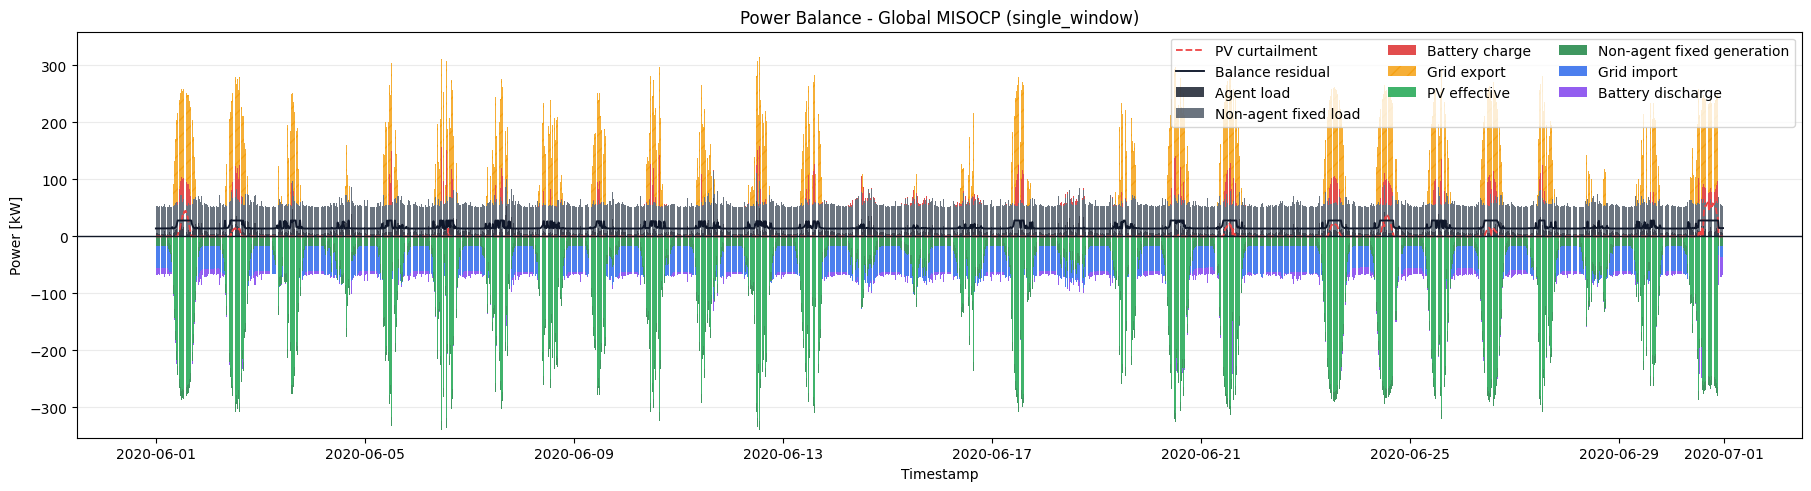

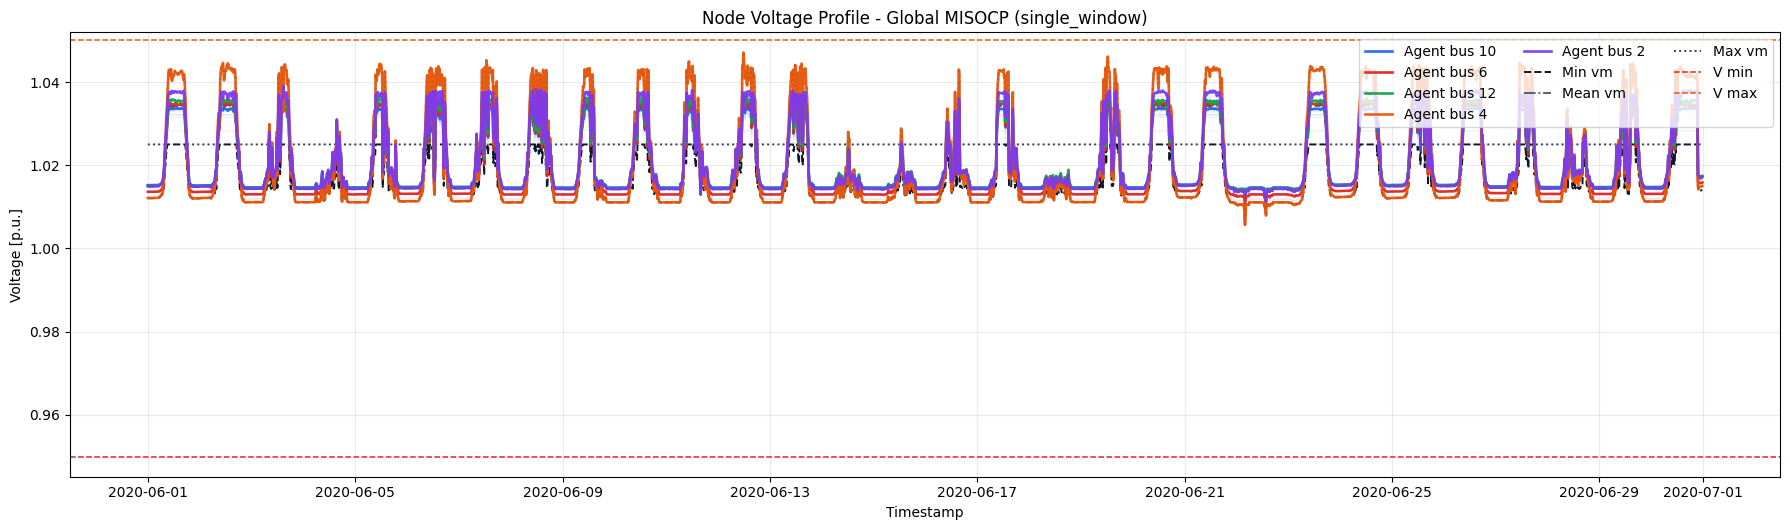

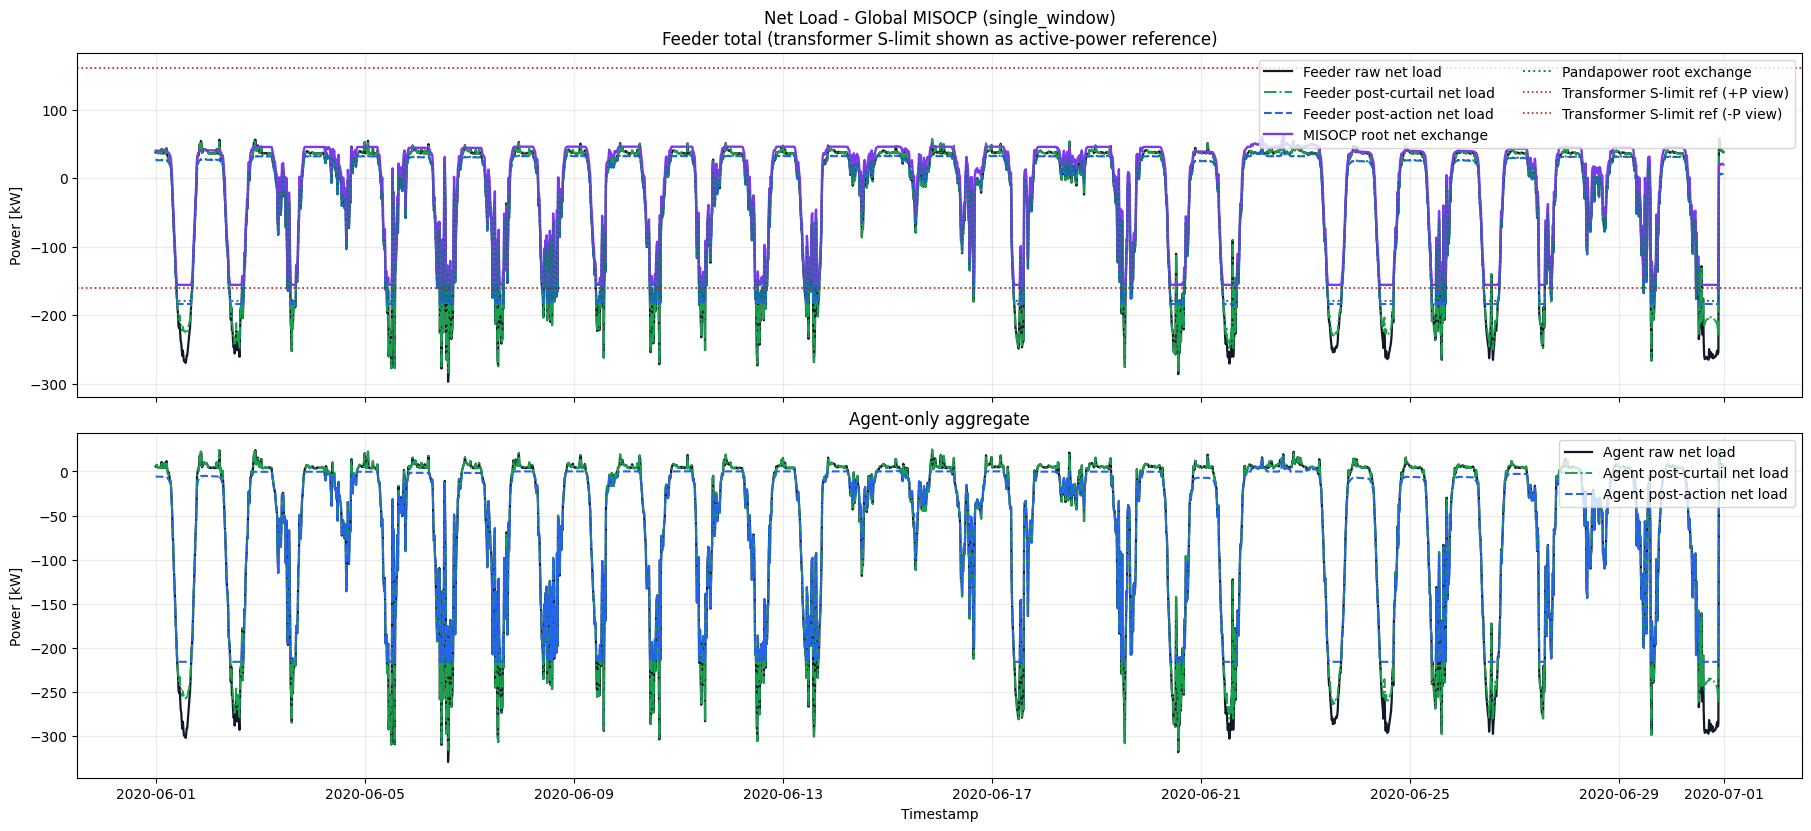

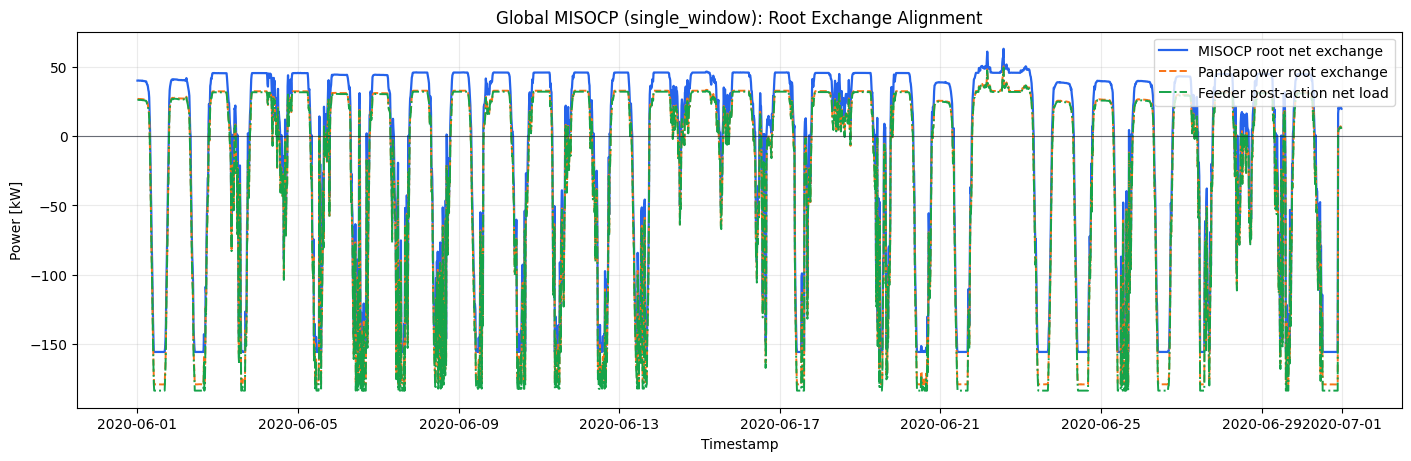

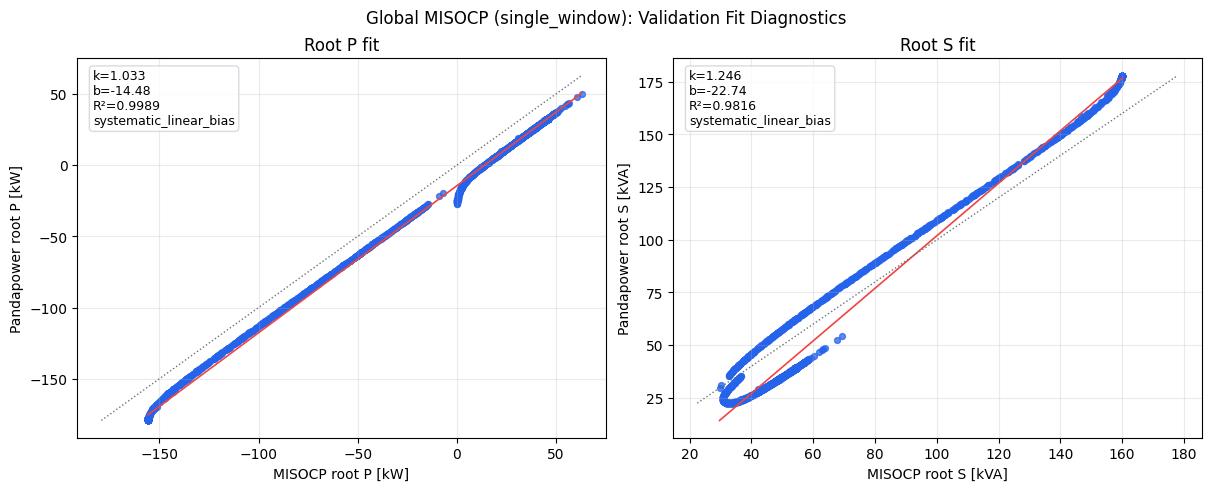

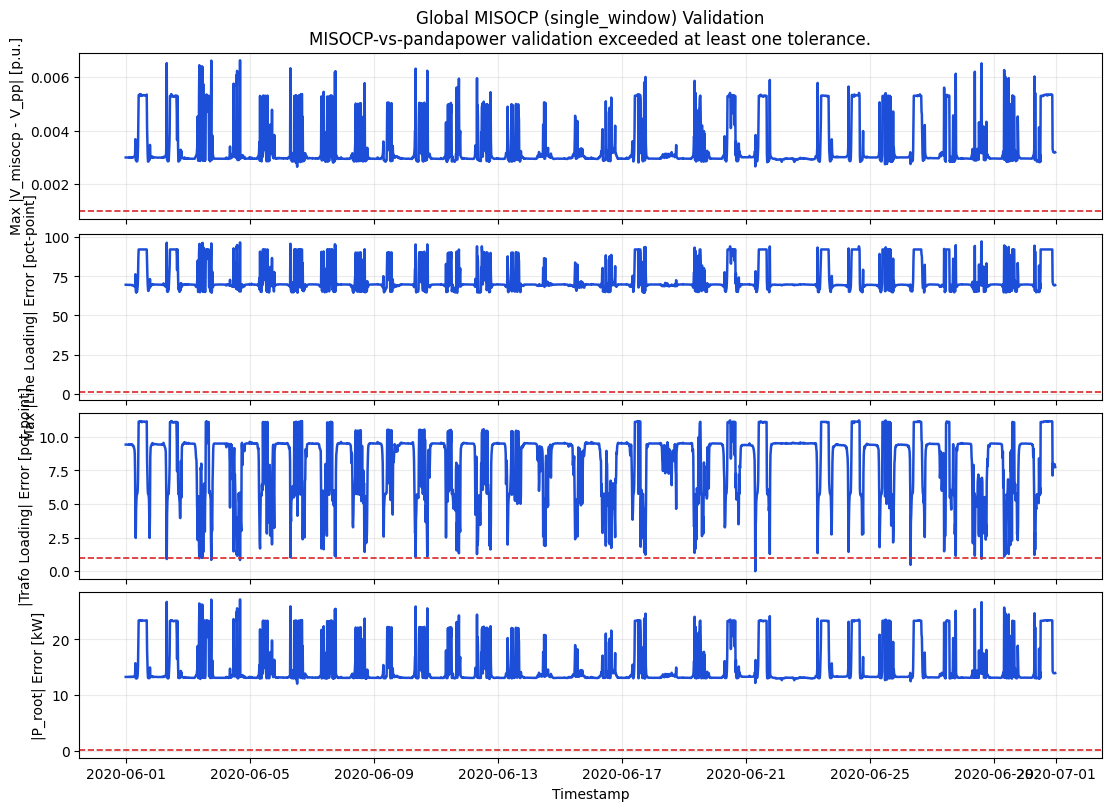

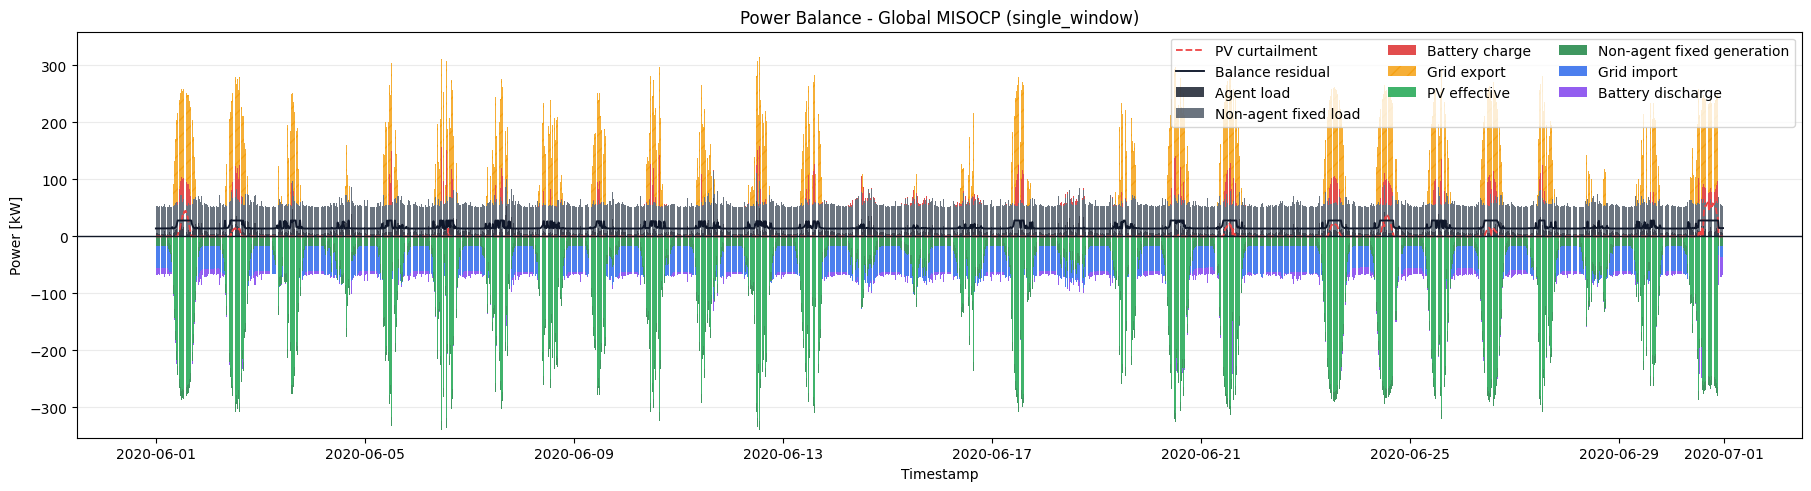

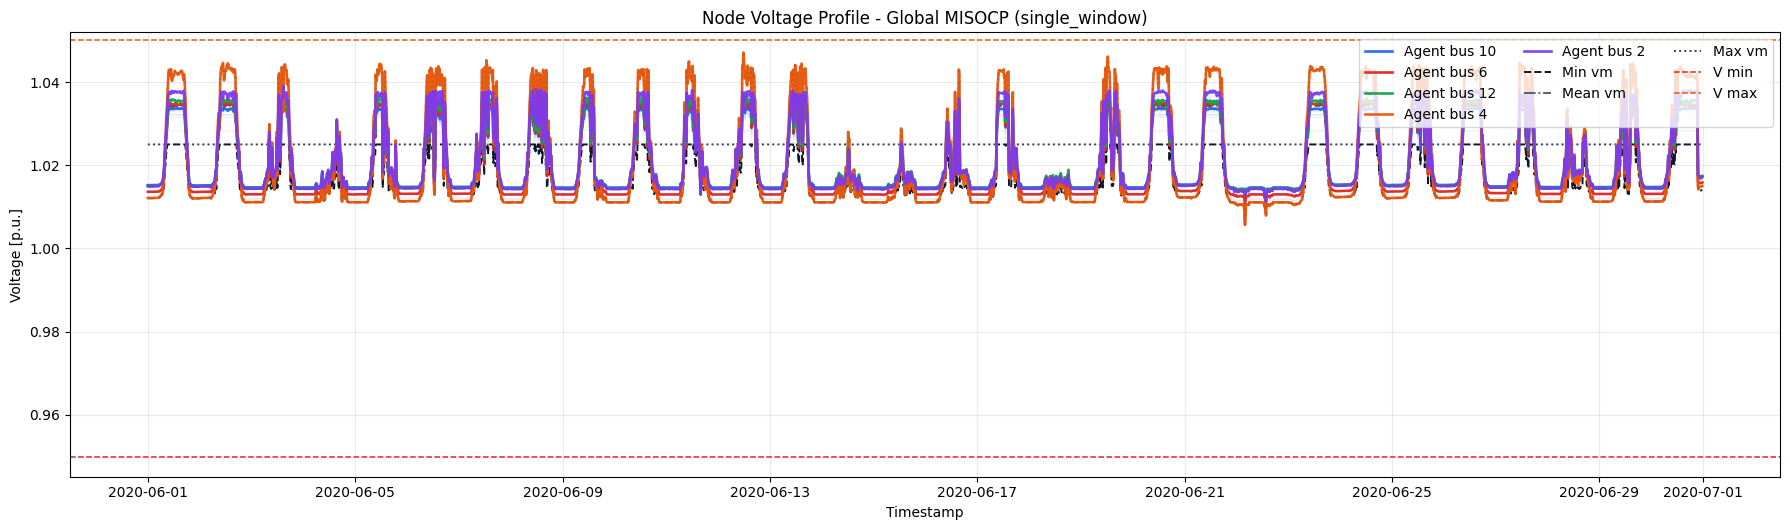

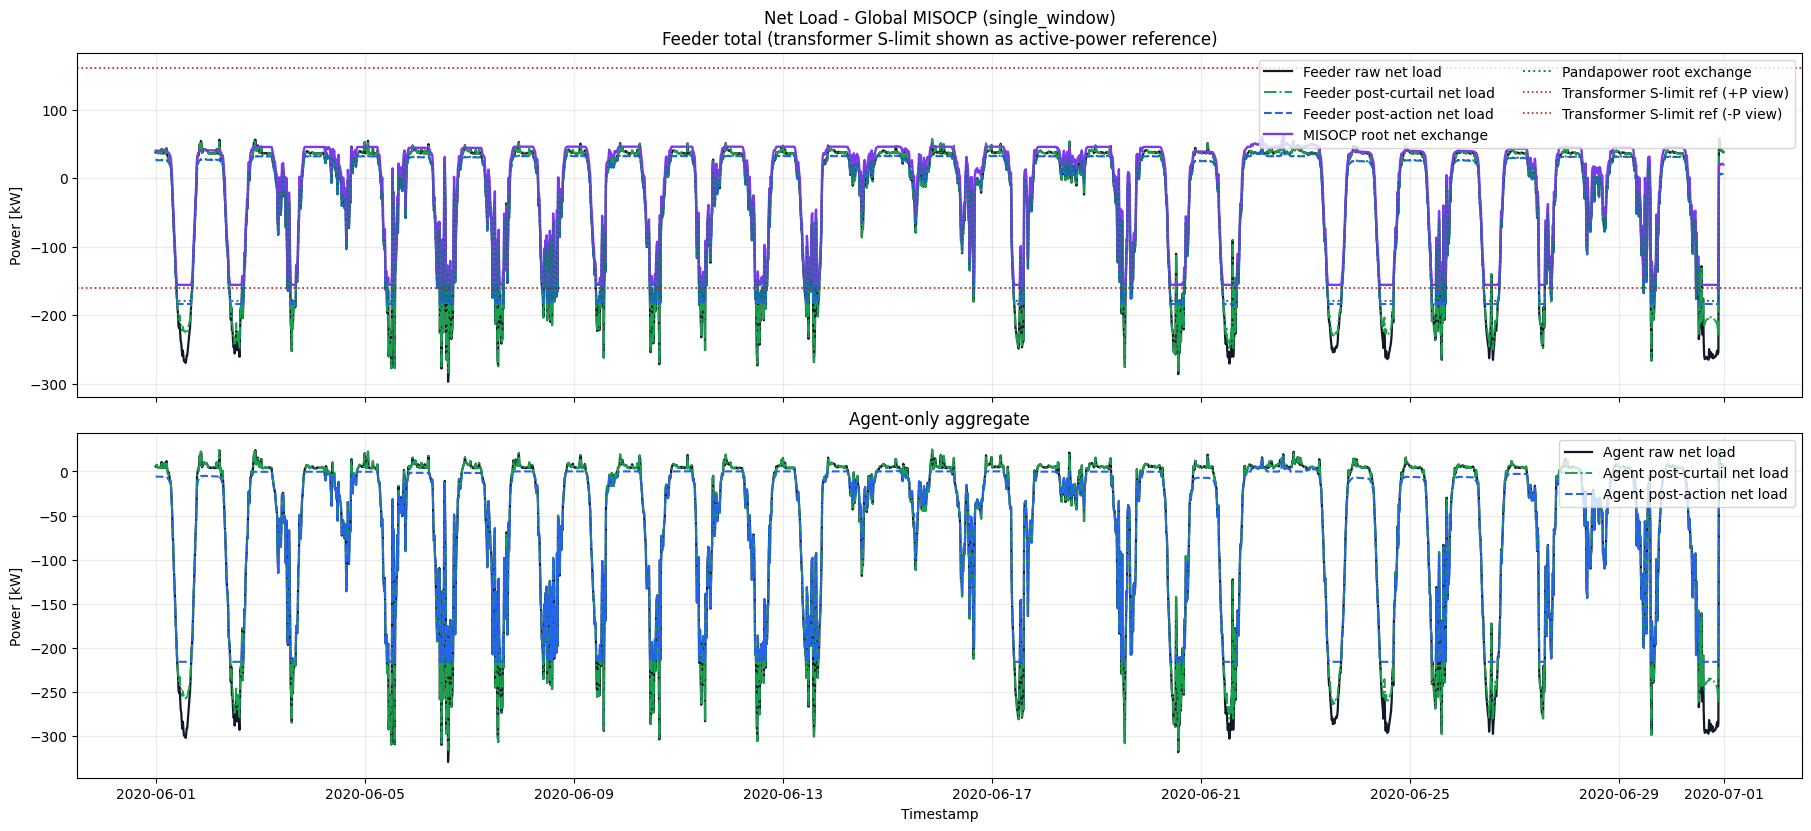

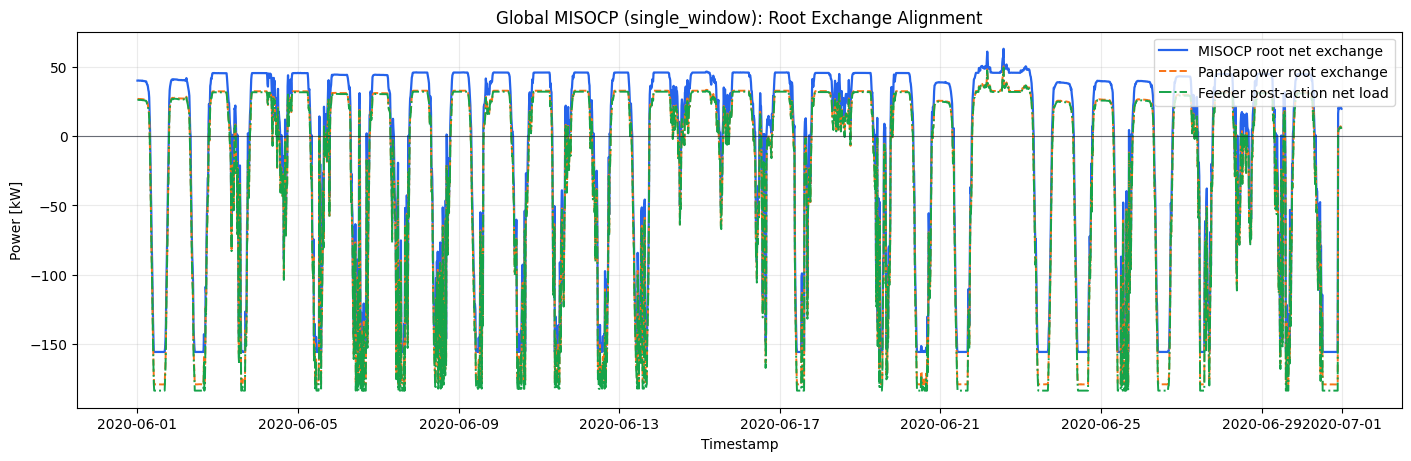

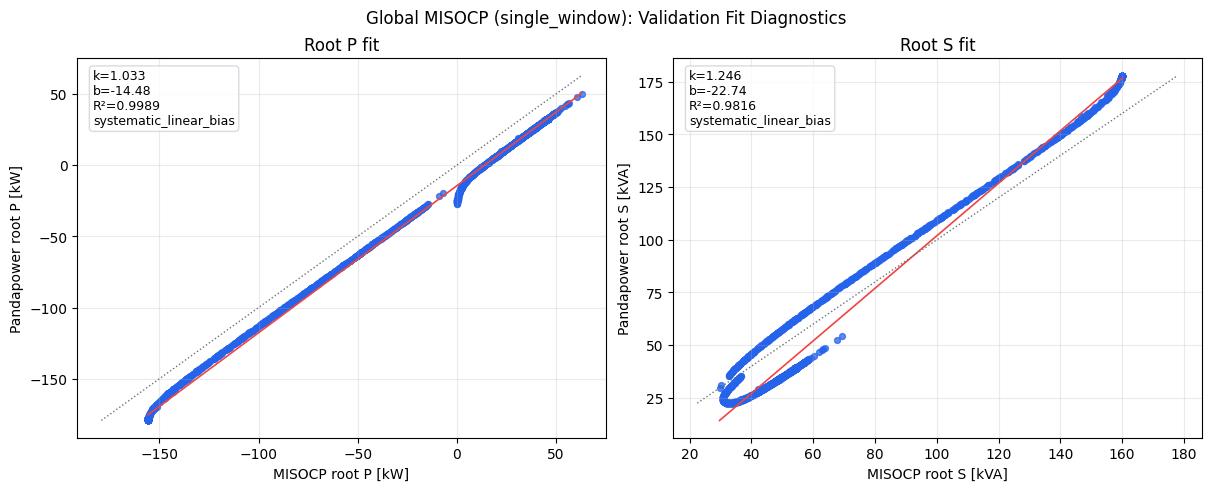

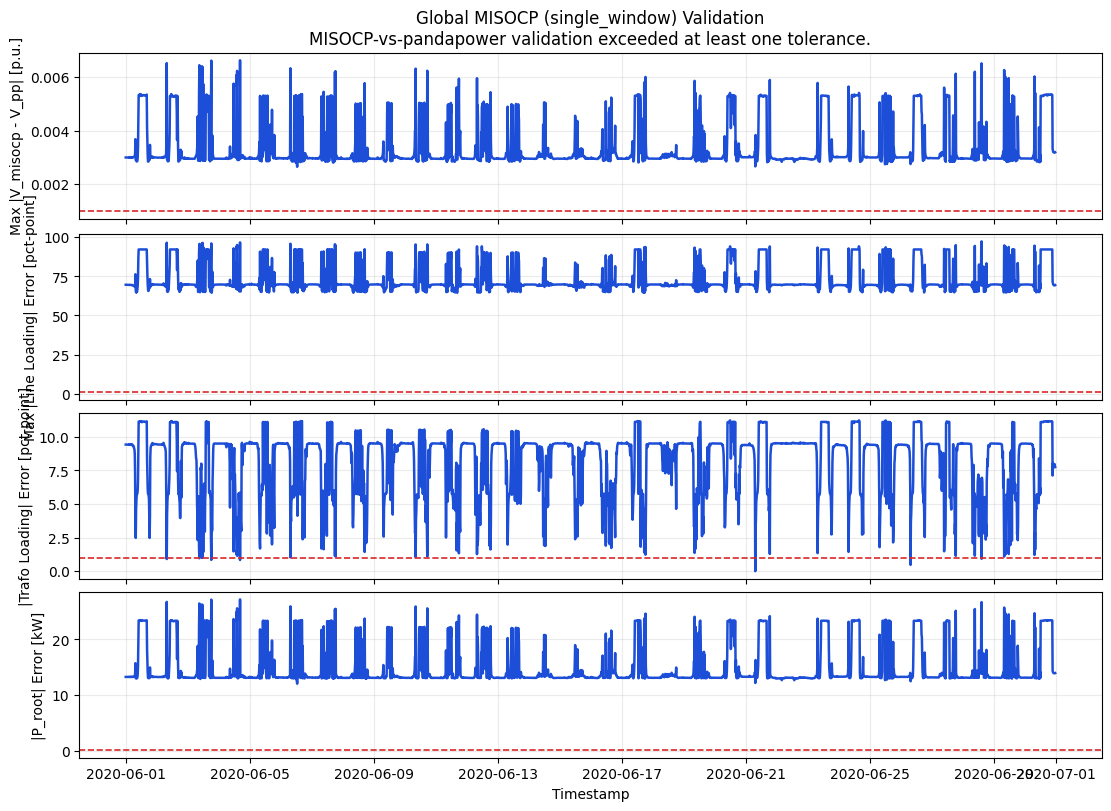

In [4]:
balance_fig = None
voltage_fig = None
net_load_fig = None
misocp_validation_fig = None
root_alignment_fig = None
validation_scatter_fig = None
if not solve_succeeded:
    print("skip plotting because solve has no incumbent")
else:
    controller_label = misocp_controller_label(solve_result.solve_mode)
    balance_fig = plot_full_horizon_power_balance(
        solve_step_df,
        controller_label=controller_label,
        dt_hours=float(problem.dt_hours),
    )
    voltage_fig = plot_full_horizon_voltage(
        solve_step_df,
        grid_voltage_df,
        agent_bus_ids=list(cfg.grid.agent_bus_ids),
        v_min_pu=float(cfg.grid.v_min_pu),
        v_max_pu=float(cfg.grid.v_max_pu),
        controller_label=controller_label,
    )
    net_load_fig = plot_full_horizon_net_load(
        solve_step_df,
        trafo_limit_kw=float(problem.trafo_limit_mva) * 1000.0,
        controller_label=controller_label,
    )
    display(balance_fig)
    display(voltage_fig)
    display(net_load_fig)
    if misocp_validation_rollout is not None and not misocp_validation_rollout.step_df.empty:
        root_alignment_fig = plot_root_exchange_alignment(
            misocp_validation_rollout.step_df,
            controller_label=controller_label,
        )
        display(root_alignment_fig)
    if not misocp_validation_df.empty:
        validation_scatter_fig = plot_misocp_validation_scatter_panel(
            misocp_validation_df,
            controller_label=controller_label,
        )
        display(validation_scatter_fig)
    if misocp_validation_rollout is not None:
        misocp_validation_fig = plot_global_misocp_validation(misocp_validation_rollout)
        display(misocp_validation_fig)
